In [1]:
pip install praat-parselmouth

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install librosa soundfile pandas tqdm matplotlib numpy praat-parselmouth

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import parselmouth
from parselmouth.praat import call
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings("ignore")

/Users/alinaejoji/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
!pip install numpy==1.26.4 pandas==2.2.2 --force-reinstall

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached pandas-2.2.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (19 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
Using cached pandas-2.2.2-cp311-cp311-macosx_11_0_arm64.whl (11.3 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Fou

In [6]:
from pathlib import Path

# Your dataset folder
DATA_ROOT = Path("/Users/alinaejoji/Documents/early_stroke_detection/dataset")

# Where to save files generated by the notebook
MANIFEST_CSV = Path("/Users/alinaejoji/Documents/early_stroke_detection/manifest.csv")
FEATURES_CSV = Path("/Users/alinaejoji/Documents/early_stroke_detection/features_full.csv")
SPLIT_CSV = Path("/Users/alinaejoji/Documents/early_stroke_detection/splits.csv")

print("Dataset folder exists:", DATA_ROOT.exists())


Dataset folder exists: True


In [7]:
import re

def parse_meta(fp):
    path = Path(fp)
    parent = path.parent.name     # e.g., wav_arrayMic_FC01S01
    group_folder = path.parents[1].name  # e.g., F_Con, M_Dys

    # label and gender based on group_folder
    label = "dysarthric" if "Dys" in group_folder else "control"
    gender = "female" if group_folder.startswith("F") else "male"

    # Extract mic type
    mic = "headMic" if "headMic" in parent else "arrayMic"

    # Extract speaker (FC01, F03, M02 etc.)
    speaker_match = re.search(r'(FC\d+|F\d+|MC\d+|M\d+)', parent)
    speaker = speaker_match.group(1) if speaker_match else None

    # Extract session number (S01, S02...)
    session_match = re.search(r'(S\d+)', parent)
    session = session_match.group(1) if session_match else None

    return {
        "group": group_folder,
        "speaker": speaker,
        "session": session,
        "mic": mic,
        "label": label,
        "gender": gender
    }


In [8]:
# rebuild manifest using new parse function
rows = []
for root, dirs, files in os.walk(DATA_ROOT):
    for fname in files:
        if fname.lower().endswith(".wav"):
            fp = str(Path(root)/fname)
            meta = parse_meta(fp)
            rows.append({"filepath": fp, **meta})

df = pd.DataFrame(rows)
df.to_csv(MANIFEST_CSV, index=False)
print("Manifest rows:", len(df))
df.head()


Manifest rows: 17635


,filepath,group,speaker,session,mic,label,gender
0,/Users/alinaejoji/Documents/early_stroke_detec...,F_Dys,F04,S02,arrayMic,dysarthric,female
1,/Users/alinaejoji/Documents/early_stroke_detec...,F_Dys,F04,S02,arrayMic,dysarthric,female
2,/Users/alinaejoji/Documents/early_stroke_detec...,F_Dys,F04,S02,arrayMic,dysarthric,female
3,/Users/alinaejoji/Documents/early_stroke_detec...,F_Dys,F04,S02,arrayMic,dysarthric,female
4,/Users/alinaejoji/Documents/early_stroke_detec...,F_Dys,F04,S02,arrayMic,dysarthric,female


In [9]:
df.groupby(["group","speaker","session","mic","label"]).size()


group  speaker  session  mic       label     
F_Con  FC01     S01      arrayMic  control        256
                         headMic   control        164
       FC02     S02      arrayMic  control        269
                S03      arrayMic  control        992
                         headMic   control       1000
       FC03     S01      arrayMic  control        400
                         headMic   control        405
                S02      arrayMic  control        387
                         headMic   control        390
                S03      arrayMic  control        208
                         headMic   control        207
F_Dys  F03      S01      arrayMic  dysarthric     204
                         headMic   dysarthric     204
                S02      arrayMic  dysarthric     435
                         headMic   dysarthric     159
                S03      arrayMic  dysarthric     209
                         headMic   dysarthric     214
       F04      S01      arrayMic  d

In [10]:
# ---------- FEATURE EXTRACTION (DEBUG MODE) ----------
import os
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import parselmouth
from parselmouth.praat import call
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ---------- CONFIG ----------
PROJECT_ROOT = Path("/Users/alinaejoji/Documents/early_stroke_detection")
DATA_ROOT = PROJECT_ROOT / "dataset"
MANIFEST_CSV = PROJECT_ROOT / "manifest.csv"
DEBUG = True     # set to False later for full extraction
DEBUG_N = 5      # process only 5 files for testing
TARGET_SR = 16000
N_MFCC = 13
# ----------------------------

df = pd.read_csv(MANIFEST_CSV)

# select sample files
if DEBUG:
    df_proc = df.sample(min(DEBUG_N, len(df)), random_state=42)
else:
    df_proc = df.copy()

print("Processing", len(df_proc), "files in debug mode.")
print(df_proc[['filepath','speaker','session','mic']].head(), "\n")

# --------- FEATURE HELPERS ---------

def compute_jitter_shimmer_hnr(filepath):
    try:
        snd = parselmouth.Sound(str(filepath))
        pp = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter_local = call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer_local = call([snd, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harm = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr_mean = call(harm, "Get mean", 0, 0)
        return jitter_local, shimmer_local, hnr_mean
    except:
        return None, None, None


def extract_features(fp):
    y, sr = librosa.load(fp, sr=TARGET_SR)

    out = {
        "filepath": fp,
        "duration_s": len(y) / sr,
        "rms": np.mean(librosa.feature.rms(y=y)),
        "zcr": np.mean(librosa.feature.zero_crossing_rate(y))
    }

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    for i in range(N_MFCC):
        out[f"mfcc{i+1}_mean"] = float(np.mean(mfcc[i]))
        out[f"mfcc{i+1}_std"] = float(np.std(mfcc[i]))

    # Pitch (F0)
    try:
        f0, _, _ = librosa.pyin(y, fmin=80, fmax=350)
        out["f0_mean"] = float(np.nanmean(f0))
    except:
        out["f0_mean"] = None

    # Jitter, Shimmer, HNR
    j, s, h = compute_jitter_shimmer_hnr(fp)
    out["jitter_local"] = j
    out["shimmer_local"] = s
    out["hnr_mean"] = h

    return out

# --------- PROCESS FILES ---------
feature_list = []

for _, row in tqdm(df_proc.iterrows(), total=len(df_proc)):
    feats = extract_features(row["filepath"])
    feats.update({
        "speaker": row["speaker"],
        "session": row["session"],
        "mic": row["mic"],
        "label": row["label"],
        "gender": row["gender"]
    })
    feature_list.append(feats)

feat_df = pd.DataFrame(feature_list)

# save debug features
debug_path = PROJECT_ROOT / "features_debug.csv"
feat_df.to_csv(debug_path, index=False)

print("\nSaved features to:", debug_path)
print(feat_df.head())


Processing 5 files in debug mode.
                                                filepath speaker session  \
15459  /Users/alinaejoji/Documents/early_stroke_detec...     M02     S02   
4688   /Users/alinaejoji/Documents/early_stroke_detec...    FC01     S01   
4639   /Users/alinaejoji/Documents/early_stroke_detec...    FC01     S01   
13441  /Users/alinaejoji/Documents/early_stroke_detec...    MC03     S01   
9410   /Users/alinaejoji/Documents/early_stroke_detec...    MC03     S01   

            mic  
15459   headMic  
4688   arrayMic  
4639   arrayMic  
13441  arrayMic  
9410    headMic   



100%|█████████████████████████████████████████████| 5/5 [00:02<00:00,  1.92it/s]


Saved features to: /Users/alinaejoji/Documents/early_stroke_detection/features_debug.csv
                                            filepath  duration_s       rms  \
0  /Users/alinaejoji/Documents/early_stroke_detec...       7.345  0.206898   
1  /Users/alinaejoji/Documents/early_stroke_detec...       2.250  0.006615   
2  /Users/alinaejoji/Documents/early_stroke_detec...       3.000  0.004017   
3  /Users/alinaejoji/Documents/early_stroke_detec...       1.350  0.014344   
4  /Users/alinaejoji/Documents/early_stroke_detec...       1.645  0.078887   

        zcr  mfcc1_mean   mfcc1_std  mfcc2_mean  mfcc2_std  mfcc3_mean  \
0  0.062965 -177.405090  119.513206  107.915222  29.039951   11.223087   
1  0.568710 -398.794952   53.242737    2.532460  28.646715   25.943491   
2  0.615281 -407.248749   43.696461   -1.972117  26.927757   29.128431   
3  0.484341 -358.386993   92.448189   25.713648  43.297260   23.692408   
4  0.063232 -159.967422   37.111443   81.229050  28.553598    5.997199 

In [11]:
import pandas as pd
df_feat = pd.read_csv("/Users/alinaejoji/Documents/early_stroke_detection/features_debug.csv")
df_feat.head()


,filepath,duration_s,rms,zcr,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,...,mfcc13_std,f0_mean,jitter_local,shimmer_local,hnr_mean,speaker,session,mic,label,gender
0,/Users/alinaejoji/Documents/early_stroke_detec...,7.345,0.206898,0.062965,-177.405090,119.513206,107.915222,29.039951,11.223087,25.074694,...,9.600674,232.277570,0.029389,0.105840,13.152308,M02,S02,headMic,dysarthric,male
1,/Users/alinaejoji/Documents/early_stroke_detec...,2.250,0.006615,0.568710,-398.794952,53.242737,2.532460,28.646715,25.943491,19.410019,...,4.216259,273.627127,0.014865,0.103231,8.610636,FC01,S01,arrayMic,control,female
2,/Users/alinaejoji/Documents/early_stroke_detec...,3.000,0.004017,0.615281,-407.248749,43.696461,-1.972117,26.927757,29.128431,14.455032,...,4.320561,NaN,0.027850,0.197002,4.370222,FC01,S01,arrayMic,control,female
3,/Users/alinaejoji/Documents/early_stroke_detec...,1.350,0.014344,0.484341,-358.386993,92.448189,25.713648,43.297260,23.692408,30.921858,...,6.426924,NaN,0.030108,0.225382,6.249502,MC03,S01,arrayMic,control,male
4,/Users/alinaejoji/Documents/early_stroke_detec...,1.645,0.078887,0.063232,-159.967422,37.111443,81.229050,28.553598,5.997199,6.713648,...,2.592534,82.790084,0.034151,0.106097,5.682284,MC03,S01,headMic,control,male


In [12]:
df_feat.shape, df_feat.dtypes


((5, 39),
 filepath          object
 duration_s       float64
 rms              float64
 zcr              float64
 mfcc1_mean       float64
 mfcc1_std        float64
 mfcc2_mean       float64
 mfcc2_std        float64
 mfcc3_mean       float64
 mfcc3_std        float64
 mfcc4_mean       float64
 mfcc4_std        float64
 mfcc5_mean       float64
 mfcc5_std        float64
 mfcc6_mean       float64
 mfcc6_std        float64
 mfcc7_mean       float64
 mfcc7_std        float64
 mfcc8_mean       float64
 mfcc8_std        float64
 mfcc9_mean       float64
 mfcc9_std        float64
 mfcc10_mean      float64
 mfcc10_std       float64
 mfcc11_mean      float64
 mfcc11_std       float64
 mfcc12_mean      float64
 mfcc12_std       float64
 mfcc13_mean      float64
 mfcc13_std       float64
 f0_mean          float64
 jitter_local     float64
 shimmer_local    float64
 hnr_mean         float64
 speaker           object
 session           object
 mic               object
 label             object
 g

In [13]:
df_feat.isnull().sum().sort_values(ascending=False).head(20)


f0_mean          2
mfcc13_std       0
mfcc10_mean      0
mfcc10_std       0
mfcc11_mean      0
mfcc11_std       0
mfcc12_mean      0
mfcc12_std       0
mfcc13_mean      0
filepath         0
mfcc9_mean       0
jitter_local     0
shimmer_local    0
hnr_mean         0
speaker          0
session          0
mic              0
label            0
mfcc9_std        0
mfcc8_std        0
dtype: int64

In [14]:
df_feat['duration_s'].describe()


count    5.000000
mean     3.118000
std      2.445937
min      1.350000
25%      1.645000
50%      2.250000
75%      3.000000
max      7.345000
Name: duration_s, dtype: float64

In [15]:
print("jitter_local min/median/max:", df_feat['jitter_local'].min(), df_feat['jitter_local'].median(), df_feat['jitter_local'].max())
print("shimmer_local min/median/max:", df_feat['shimmer_local'].min(), df_feat['shimmer_local'].median(), df_feat['shimmer_local'].max())
print("f0_mean min/median/max:", df_feat['f0_mean'].min(), df_feat['f0_mean'].median(), df_feat['f0_mean'].max())


jitter_local min/median/max: 0.0148654375804019 0.0293890500182302 0.034151379504744
shimmer_local min/median/max: 0.1032308331793026 0.1060966385548342 0.2253819506982523
f0_mean min/median/max: 82.79008423497342 232.2775702340096 273.6271268175609


In [16]:
df_feat['jitter_local'] = pd.to_numeric(df_feat['jitter_local'], errors='coerce')
df_feat['shimmer_local'] = pd.to_numeric(df_feat['shimmer_local'], errors='coerce')
df_feat['f0_mean'] = pd.to_numeric(df_feat['f0_mean'], errors='coerce')


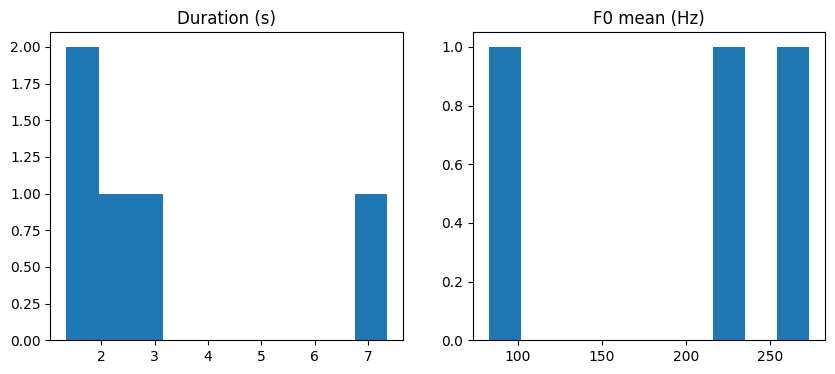

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_feat['duration_s'].dropna(), bins=10)
plt.title('Duration (s)')
plt.subplot(1,2,2)
plt.hist(df_feat['f0_mean'].dropna(), bins=10)
plt.title('F0 mean (Hz)')
plt.show()


In [18]:
df_feat[['filepath','speaker','session','mic','label']].sample(5, random_state=1)


,filepath,speaker,session,mic,label
2,/Users/alinaejoji/Documents/early_stroke_detec...,FC01,S01,arrayMic,control
1,/Users/alinaejoji/Documents/early_stroke_detec...,FC01,S01,arrayMic,control
4,/Users/alinaejoji/Documents/early_stroke_detec...,MC03,S01,headMic,control
0,/Users/alinaejoji/Documents/early_stroke_detec...,M02,S02,headMic,dysarthric
3,/Users/alinaejoji/Documents/early_stroke_detec...,MC03,S01,arrayMic,control


In [19]:
# ---------- FULL FEATURE EXTRACTION (NO DEBUG) ----------
import os
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import parselmouth
from parselmouth.praat import call
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ---------- CONFIG ----------
PROJECT_ROOT = Path("/Users/alinaejoji/Documents/early_stroke_detection")
DATA_ROOT = PROJECT_ROOT / "dataset"
MANIFEST_CSV = PROJECT_ROOT / "manifest.csv"
FEATURES_CSV = PROJECT_ROOT / "features_full.csv"
SPLIT_CSV = PROJECT_ROOT / "splits.csv"

TARGET_SR = 16000
N_MFCC = 13
# ----------------------------

df = pd.read_csv(MANIFEST_CSV)
print("Total files in manifest:", len(df))

# ---------- feature helpers ----------
def compute_jitter_shimmer_hnr(filepath):
    try:
        snd = parselmouth.Sound(str(filepath))
        pp = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter_local = call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer_local = call([snd, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harm = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr_mean = call(harm, "Get mean", 0, 0)
        return jitter_local, shimmer_local, hnr_mean
    except Exception:
        return None, None, None

def extract_features(fp):
    # load audio
    try:
        y, sr = librosa.load(fp, sr=TARGET_SR)
    except Exception:
        data, sr0 = sf.read(fp)
        if sr0 != TARGET_SR:
            y = librosa.resample(data.astype(float), sr0, TARGET_SR)
            sr = TARGET_SR
        else:
            y = data
            sr = sr0

    out = {
        "filepath": fp,
        "duration_s": float(len(y) / sr),
        "rms": float(np.mean(librosa.feature.rms(y=y))),
        "zcr": float(np.mean(librosa.feature.zero_crossing_rate(y)))
    }

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    for i in range(N_MFCC):
        out[f"mfcc{i+1}_mean"] = float(np.mean(mfcc[i]))
        out[f"mfcc{i+1}_std"] = float(np.std(mfcc[i]))

    # F0
    try:
        f0, _, _ = librosa.pyin(y, fmin=80, fmax=350)
        out["f0_mean"] = float(np.nanmean(f0))
        out["f0_median"] = float(np.nanmedian(f0))
        out["f0_std"] = float(np.nanstd(f0))
    except Exception:
        out["f0_mean"] = out["f0_median"] = out["f0_std"] = None

    # jitter/shimmer/hnr
    j, s, h = compute_jitter_shimmer_hnr(fp)
    out["jitter_local"] = j
    out["shimmer_local"] = s
    out["hnr_mean"] = h

    return out

# ---------- Run full extraction ----------
rows = df.to_dict(orient='records')
features = []
errors = []

print("\nExtracting features from", len(rows), "files...\n")
for r in tqdm(rows):
    fp = r['filepath']
    try:
        feats = extract_features(fp)
        feats.update({
            "speaker": r.get("speaker"),
            "session": r.get("session"),
            "mic": r.get("mic"),
            "label": r.get("label"),
            "gender": r.get("gender"),
            "group": r.get("group"),
            "filename": Path(fp).name
        })
        features.append(feats)
    except Exception as e:
        errors.append((fp, str(e)))

feat_df = pd.DataFrame(features)
feat_df.to_csv(FEATURES_CSV, index=False)

print("\nSaved features to:", FEATURES_CSV)
print("Extracted rows:", len(feat_df))

if errors:
    print("Errors:", len(errors), "sample:", errors[:3])

# ---------- Speaker-wise split ----------
import random
random.seed(42)

speakers = sorted(feat_df['speaker'].dropna().unique().tolist())
random.shuffle(speakers)

n = len(speakers)
train_cut = int(0.7 * n)
val_cut = int(0.85 * n)

train_sp = speakers[:train_cut]
val_sp = speakers[train_cut:val_cut]
test_sp = speakers[val_cut:]

def assign_split(sp):
    if sp in train_sp: return "train"
    if sp in val_sp: return "val"
    return "test"

feat_df["split"] = feat_df["speaker"].apply(assign_split)
feat_df.to_csv(FEATURES_CSV, index=False)

split_df = feat_df[["speaker","label","gender","group"]].drop_duplicates()
split_df["split"] = split_df["speaker"].apply(assign_split)
split_df.to_csv(SPLIT_CSV, index=False)

print("\nSaved speaker splits to:", SPLIT_CSV)
print("Speakers:", len(speakers), "=> Train/Val/Test:", len(train_sp), len(val_sp), len(test_sp))


Total files in manifest: 17635

Extracting features from 17635 files...



100%|█████████████████████████████████████| 17635/17635 [58:49<00:00,  5.00it/s]



Saved features to: /Users/alinaejoji/Documents/early_stroke_detection/features_full.csv
Extracted rows: 17632
Errors: 3 sample: [('/Users/alinaejoji/Documents/early_stroke_detection/dataset/F_Dys/wav_headMic_F01/wav_headMic_F01_0067.wav', "Error opening '/Users/alinaejoji/Documents/early_stroke_detection/dataset/F_Dys/wav_headMic_F01/wav_headMic_F01_0067.wav': Format not recognised."), ('/Users/alinaejoji/Documents/early_stroke_detection/dataset/F_Dys/wav_headMic_F01/wav_headMic_F01_0068.wav', "Error opening '/Users/alinaejoji/Documents/early_stroke_detection/dataset/F_Dys/wav_headMic_F01/wav_headMic_F01_0068.wav': Format not recognised."), ('/Users/alinaejoji/Documents/early_stroke_detection/dataset/F_Con/wav_arrayMic_FC01S01/wav_arrayMic_FC01S01_0256.wav', "can't extend empty axis 0 using modes other than 'constant' or 'empty'")]

Saved speaker splits to: /Users/alinaejoji/Documents/early_stroke_detection/splits.csv
Speakers: 15 => Train/Val/Test: 10 2 3


In [23]:
from sklearn.model_selection import train_test_split

# X and y
X = df[feature_cols]
y = df["label_num"]

# stratified 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", y_train.value_counts().to_dict())
print("Val  :", y_val.value_counts().to_dict())
print("Test :", y_test.value_counts().to_dict())


Train: {0: 6157, 1: 3690}
Val  : {0: 1319, 1: 791}
Test : {0: 1320, 1: 791}


In [21]:
!pip install xgboost


Loaded features: (17632, 44)
Using 35 features

Label counts after split:
Train: {0: 6157, 1: 3690}
Val  : {0: 1319, 1: 791}
Test : {0: 1320, 1: 791}

--- Training: Logistic Regression ---
Test Accuracy : 0.8404
Test Precision: 0.8224
Test Recall   : 0.7320
Test F1 Score : 0.7746

Classification Report (test):
               precision    recall  f1-score   support

           0     0.8493    0.9053    0.8764      1320
           1     0.8224    0.7320    0.7746       791

    accuracy                         0.8404      2111
   macro avg     0.8359    0.8186    0.8255      2111
weighted avg     0.8393    0.8404    0.8383      2111



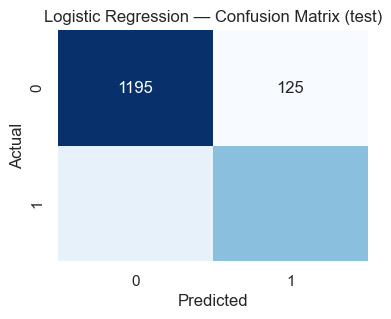

Saved model to /Users/alinaejoji/Documents/early_stroke_detection/Logistic_Regression.joblib

--- Training: SVM (RBF Kernel) ---
Test Accuracy : 0.9612
Test Precision: 0.9708
Test Recall   : 0.9241
Test F1 Score : 0.9469

Classification Report (test):
               precision    recall  f1-score   support

           0     0.9558    0.9833    0.9694      1320
           1     0.9708    0.9241    0.9469       791

    accuracy                         0.9612      2111
   macro avg     0.9633    0.9537    0.9581      2111
weighted avg     0.9614    0.9612    0.9610      2111



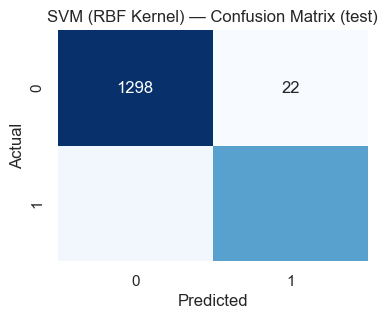

Saved model to /Users/alinaejoji/Documents/early_stroke_detection/SVM_RBF_Kernel.joblib

--- Training: Random Forest ---
Test Accuracy : 0.9602
Test Precision: 0.9732
Test Recall   : 0.9191
Test F1 Score : 0.9454

Classification Report (test):
               precision    recall  f1-score   support

           0     0.9531    0.9848    0.9687      1320
           1     0.9732    0.9191    0.9454       791

    accuracy                         0.9602      2111
   macro avg     0.9632    0.9520    0.9570      2111
weighted avg     0.9606    0.9602    0.9600      2111



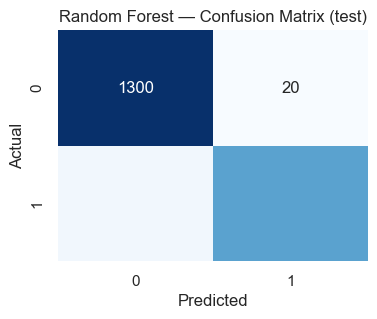

Saved model to /Users/alinaejoji/Documents/early_stroke_detection/Random_Forest.joblib

--- Training: XGBoost ---
Test Accuracy : 0.9721
Test Precision: 0.9716
Test Recall   : 0.9532
Test F1 Score : 0.9623

Classification Report (test):
               precision    recall  f1-score   support

           0     0.9723    0.9833    0.9778      1320
           1     0.9716    0.9532    0.9623       791

    accuracy                         0.9721      2111
   macro avg     0.9720    0.9683    0.9701      2111
weighted avg     0.9720    0.9721    0.9720      2111



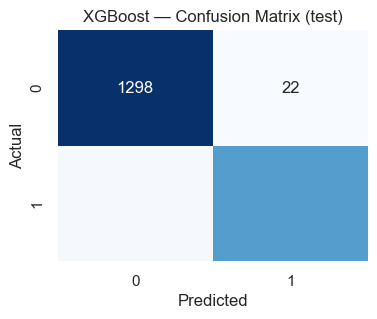

Saved model to /Users/alinaejoji/Documents/early_stroke_detection/XGBoost.joblib


===== MODEL COMPARISON =====

                 Model  Accuracy  Precision    Recall        F1
0              XGBoost  0.972051   0.971649  0.953224  0.962348
1     SVM (RBF Kernel)  0.961156   0.970784  0.924147  0.946891
2        Random Forest  0.960208   0.973226  0.919090  0.945384
3  Logistic Regression  0.840360   0.822443  0.731985  0.774582

Best model by F1: XGBoost (F1=0.9623)


In [22]:
# ---------------- FULL MODEL PIPELINE (sample-level stratified splits) ----------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
sns.set()

# ---------- CONFIG ----------
PROJECT_ROOT = "/Users/alinaejoji/Documents/early_stroke_detection"
FEATURES_PATH = f"{PROJECT_ROOT}/features_full.csv"
RANDOM_SEED = 42
# ----------------------------

# ---------- LOAD FEATURES ----------
df = pd.read_csv(FEATURES_PATH)
print("Loaded features:", df.shape)

# ensure numeric label
if "label_num" not in df.columns:
    df["label_num"] = df["label"].map({"control":0, "dysarthric":1})

# drop rows missing core features
df = df.dropna(subset=["jitter_local", "shimmer_local", "f0_mean"])
df = df.fillna(0)

# choose feature columns (exclude metadata)
ignore_cols = ["filepath", "filename", "group", "session", "speaker", "mic",
               "gender", "label", "label_num", "split"]
feature_cols = [c for c in df.columns if c not in ignore_cols]
print("Using", len(feature_cols), "features")

X_all = df[feature_cols]
y_all = df["label_num"]

# ---------- STRATIFIED SAMPLE-LEVEL SPLITS (70/15/15) ----------
# First split train / temp (train=70%, temp=30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=RANDOM_SEED
)

# Then split temp -> val/test (each 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)

print("\nLabel counts after split:")
print("Train:", y_train.value_counts().to_dict())
print("Val  :", y_val.value_counts().to_dict())
print("Test :", y_test.value_counts().to_dict())

# ---------- SCALE FEATURES ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# save scaler
joblib.dump(scaler, f"{PROJECT_ROOT}/scaler_sample_level.joblib")

# ---------- MODELS ----------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=20, random_state=RANDOM_SEED),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_SEED
    )
}

results = []

# ---------- TRAIN / EVALUATE ----------
for name, model in models.items():
    print(f"\n--- Training: {name} ---")
    model.fit(X_train_scaled, y_train)

    y_test_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"Test Accuracy : {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall   : {rec:.4f}")
    print(f"Test F1 Score : {f1:.4f}")
    print("\nClassification Report (test):\n", classification_report(y_test, y_test_pred, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"{name} — Confusion Matrix (test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Save model
    model_fname = f"{PROJECT_ROOT}/{name.replace(' ','_').replace('(','').replace(')','')}.joblib"
    joblib.dump(model, model_fname)
    print(f"Saved model to {model_fname}")

# ---------- RESULTS TABLE ----------
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)
print("\n\n===== MODEL COMPARISON =====\n")
print(results_df)

best = results_df.loc[0]
print(f"\nBest model by F1: {best['Model']} (F1={best['F1']:.4f})")


AUC: 0.996422824962648


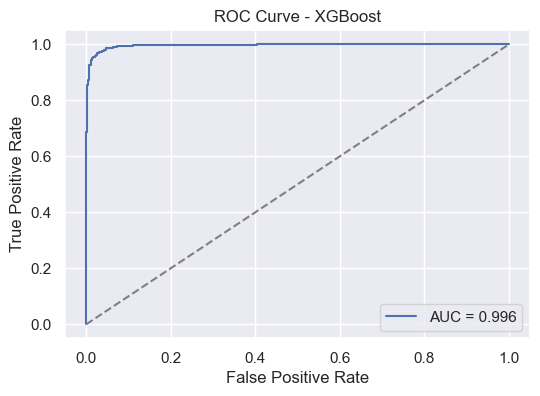

Best threshold by F1: 0.51038194 F1: 0.962962962962463


In [24]:
# ROC / AUC + threshold tuning (paste & run)
import numpy as np
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve

# load model (if needed)
import joblib
model = joblib.load("/Users/alinaejoji/Documents/early_stroke_detection/XGBoost.joblib")

# predictions: probabilities for positive class
y_proba = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# Precision-Recall & choose threshold maximizing F1
precision, recall, thr = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.nanargmax(f1_scores)
best_threshold = thr[best_idx] if best_idx < len(thr) else 0.5
print("Best threshold by F1:", best_threshold, "F1:", f1_scores[best_idx])


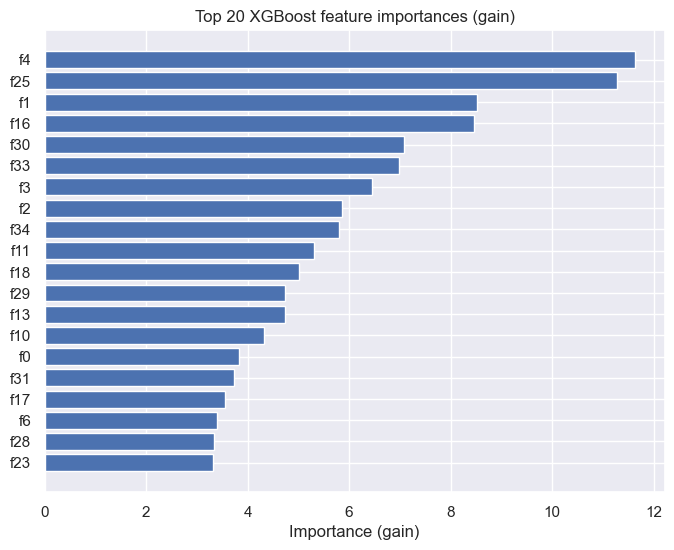

In [25]:
# Feature importance (XGBoost)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# feature_cols used earlier when training
feat_imp = model.get_booster().get_score(importance_type='gain')
# map to full list and sort
imp_df = pd.DataFrame([
    {"feature": k, "importance": v} for k, v in feat_imp.items()
])
imp_df = imp_df.sort_values("importance", ascending=False).head(20)
plt.figure(figsize=(8,6))
plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1])
plt.title("Top 20 XGBoost feature importances (gain)")
plt.xlabel("Importance (gain)")
plt.show()


In [26]:
!pip install shap

  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp311-cp311-macosx_14_0_arm64.whl (5.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.0.2 which is incompatible.
coqui-tts-trainer 0.2.2 requires tensorboard>=2.17.0, but you have tensorboard 2.11.2 which is incompatible.
torchvision 0.20.1 requires torch==2.5.1, but you have torch 2.6.0 which is incompatible.
coqui-tts 0

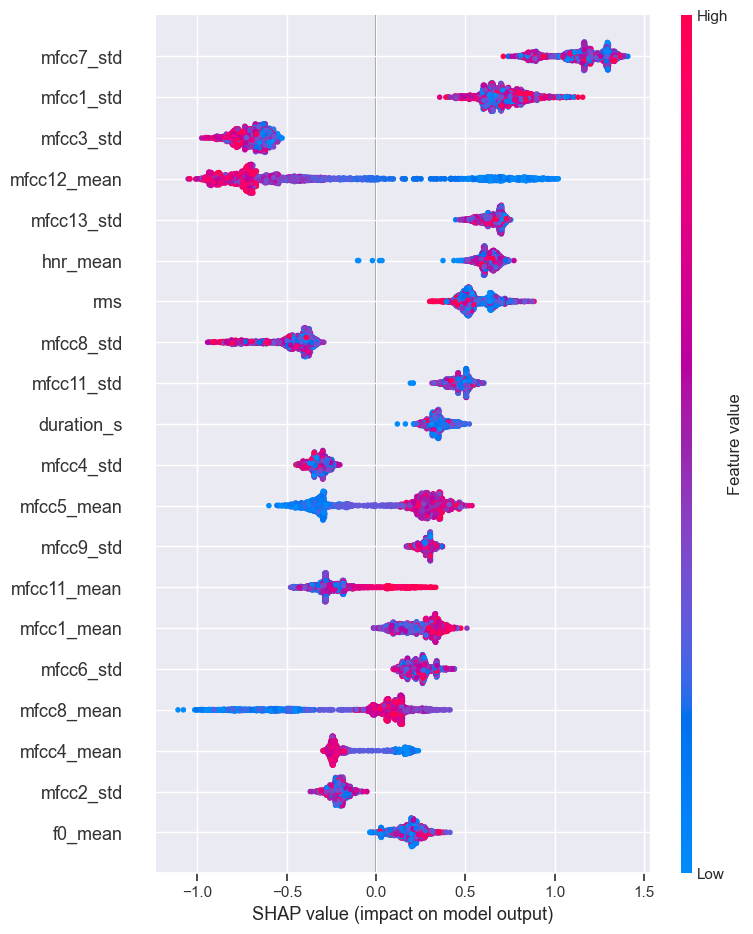

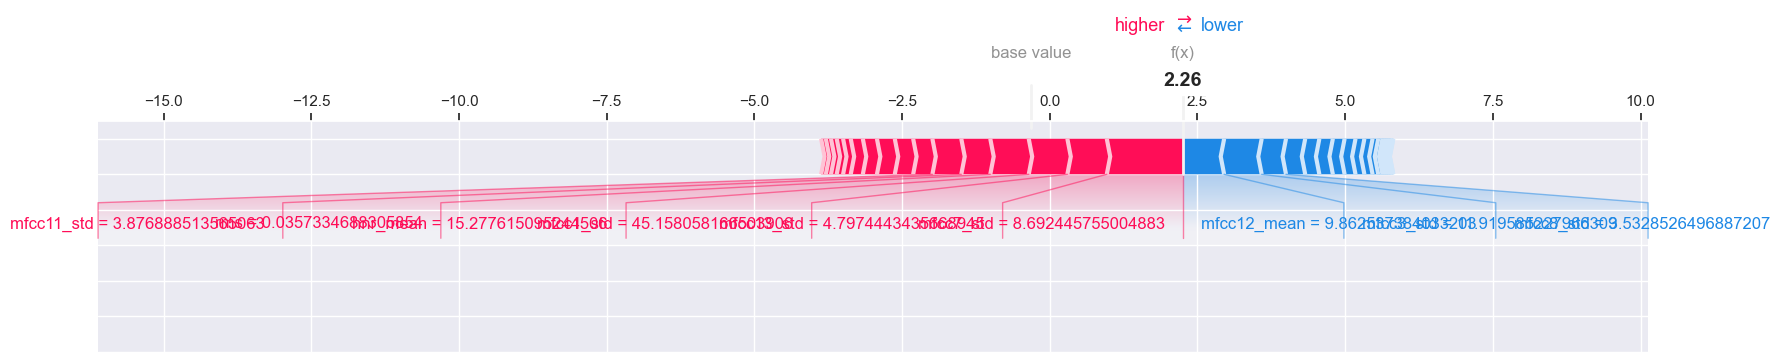

In [27]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # works for tree models

# summary plot (global)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

# explain single sample (index i)
i = 10
shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i], matplotlib=True)
